# 3차시 실습 — 데이터 준비 (II) · 모델 개발

**인공지능플랫폼 실습/설계 · 2026학년도 2학기**

---

## 이 실습의 목적

머신러닝 시스템 설계 7단계 중 **3단계 후반부와 4단계**를 다룬다.

| 단계 | 이름 | 이 노트북에서 하는 일 |
|---|---|---|
| 3 | 데이터 준비 (II) | 피처 엔지니어링을 **하나의 Pipeline 객체**로 묶는다 |
| 4 | 모델 개발 | 기준선 → 단순 모델 → 복잡한 모델 순으로 비교하고 불균형에 대응한다 |

## 오늘의 두 가지 핵심

1. **데이터 누수(data leakage)** — `fit` 은 훈련 데이터에만, `transform` 은 모두에게
2. **성능의 기준선을 명확히 한다.** — 정확도 84%가 "학습한 것이 없다"는 뜻일 수 있다

## 최종 산출물

- 모델 비교 실험표 · 불균형 대응 비교표
- **모델 카드 (산출물 ④)**
- `hr_attrition_v1.pkl` — 전처리 + 모델이 함께 저장된 파이프라인 (4차시에서 사용)

---

## 수업진행

| 절 | 내용 |
|---|---|
| 0 | 2차시 결과 재현 |
| 1 | 피처 엔지니어링 (이상치 · 파생 피처) |
| 2 | 데이터 누수 실험 |
| 3 | ColumnTransformer + Pipeline |
| 4 | 분할과 교차검증 |
| 5 | 기준선 3종 |
| 6 | 모델 7종 비교 |
| 7 | 불균형 대응 3종 |
| 8 | 딥러닝(DNN) 비교 |
| 9 | 모델 해석 · 파이프라인 저장 |


In [50]:
# ============================================================
# 0. 환경 설정 (Colab 에서 런타임을 다시 연결할 때마다 실행)
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 폰트 설정 (Colab) --------------------------------
import matplotlib.font_manager as fm, os, subprocess

def setup_korean_font():
    path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
    if not os.path.exists(path):
        try:
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                           check=False, capture_output=True)
        except Exception:
            pass
    if os.path.exists(path):
        fm.fontManager.addfont(path)
        plt.rcParams["font.family"] = "NanumBarunGothic"
    plt.rc("axes", unicode_minus=False)

setup_korean_font()
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0]
              if isinstance(plt.rcParams["font.family"], list) else plt.rcParams["font.family"])
plt.rc("axes", unicode_minus=False)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_STATE = 2026
DATA_URL = "http://joy-bae.github.io/HR-Employee-Attrition.csv"
print("환경 설정 완료 / pandas", pd.__version__)

환경 설정 완료 / pandas 3.0.3


---
# 0. 2차시 결과 재현

2차시에서 만든 **데이터 카드의 속성 유형 분류**를 그대로 가져온다.


In [51]:
df = pd.read_csv(DATA_URL)

TARGET = "Attrition"
COLUMN_TYPES = {
    "num_cont": ["Income_M", "p_SalaryHike"],
    "num_disc": ["Age", "Dist", "Companies", "YearsAtCompany", "YearsSinceLastPromotion"],
    "cat_ord":  ["Education", "JobLevel", "JobSatisfaction", "Env_Satisfaction",
                 "RelationshipSatisfaction", "Performance", "StockOption", "WorkLifeBalance"],
    "cat_nom":  ["Department", "Gender", "MaritalStatus", "OverTime"],
}
NUM_COLS = COLUMN_TYPES["num_cont"] + COLUMN_TYPES["num_disc"]
ORD_COLS = COLUMN_TYPES["cat_ord"]
CAT_COLS = COLUMN_TYPES["cat_nom"]

print("shape:", df.shape)
print("소수 클래스 비율:", f"{df[TARGET].mean():.4f}")
print("기준선 정확도  :", f"{1 - df[TARGET].mean():.4f}")

shape: (1470, 20)
소수 클래스 비율: 0.1612
기준선 정확도  : 0.8388


---
# 1. 피처 엔지니어링

피처 엔지니어링에는 두 가지 프로세스가 필요하다.
1. **도메인 지식**을 사용하여 원시 데이터에서 예상 피처를 선택하고 **추출**
2. 예측한 피처를 모델에서 **사용할 수 있는 형식으로 변환**

여기서는 ①(파생 피처 생성)을 먼저 하고, ②(변환)는 3절의 Pipeline 에서 처리한다.


### 실습 1-1. 이상치 확인 — 처리 전에 판단부터 (수업)

`Income_M` 에는 IQR 기준 이상치 후보가 여럿 있다. **이 값들을 제거할 것인가?**

그림을 그리기 전에 먼저 답해 보라.
- 월급이 유난히 높은 직원은 **입력 오류**인가, **드물지만 실재하는 값**인가?
- 그것을 무엇으로 확인할 수 있는가?

아래에서 왜도(skew)와 직급별 분포를 확인한 뒤, 판단하고 그 근거를 기록한다.


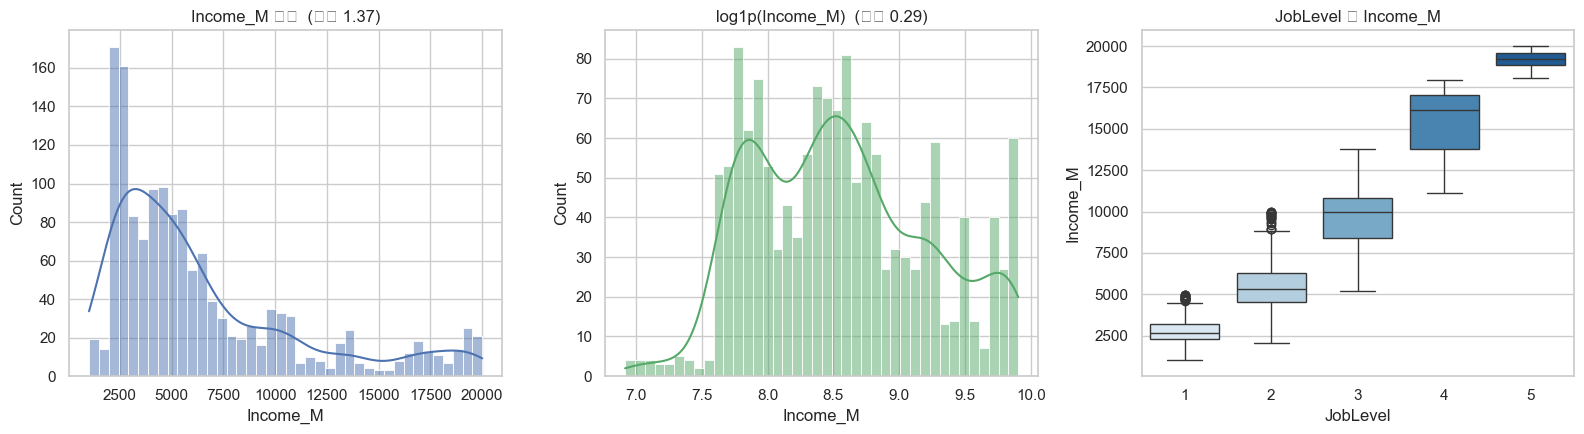

IQR 경계      : -5,291 ~ 16,581
이상치 후보   : 114건 (7.8%)
왜도          : 원본 1.37 → log1p 0.29

이상치 후보의 JobLevel 분포
JobLevel
4    45
5    69 

[판단] 이상치를 제거하지 않고 유지한다.
[근거]
  1) 이상치 후보가 JobLevel [4, 5] 에만 나타난다 → 직급과 무관하게 흩어져 있지 않다.
     입력 오류라면 직급과 상관없이 무작위로 나타나야 한다. 그렇지 않으므로
     '드물지만 실재하는 값'(고직급 고소득자)으로 본다.
  2) 퇴사 예측에서 임원급 직원은 지워야 할 잡음이 아니라 예측 대상 그 자체다.
  3) 왜도만 문제라면 제거 대신 스케일링/로그 변환으로 다룰 수 있다.
     → 3절 파이프라인에서 스케일러로 처리한다 (여기서 행을 지우지 않는다).


In [52]:
# 1-1. 이상치 확인 — 제거 여부를 '판단'한 뒤에 처리한다
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

skew_raw = df["Income_M"].skew()
sns.histplot(df["Income_M"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Income_M 원본  (왜도 {skew_raw:.2f})")

skew_log = np.log1p(df["Income_M"]).skew()
sns.histplot(np.log1p(df["Income_M"]), bins=40, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"log1p(Income_M)  (왜도 {skew_log:.2f})")

sns.boxplot(data=df, x="JobLevel", y="Income_M", ax=axes[2], palette="Blues")
axes[2].set_title("JobLevel 별 Income_M")

plt.tight_layout(); plt.show()

# --- IQR 기준 이상치 후보를 세어 본다 ---------------------------------
q1, q3 = df["Income_M"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = df[(df["Income_M"] < low) | (df["Income_M"] > high)]

print(f"IQR 경계      : {low:,.0f} ~ {high:,.0f}")
print(f"이상치 후보   : {len(out)}건 ({len(out) / len(df):.1%})")
print(f"왜도          : 원본 {skew_raw:.2f} → log1p {skew_log:.2f}\n")

print("이상치 후보의 JobLevel 분포")
print(out["JobLevel"].value_counts().sort_index().to_string(), "\n")

# --- 판단과 근거 -------------------------------------------------------
levels = sorted(int(v) for v in out["JobLevel"].unique())
concentrated = min(levels) >= 4          # 고직급에만 몰려 있는가?

print("[판단] 이상치를 제거하지 않고 유지한다.")
print("[근거]")
print(f"  1) 이상치 후보가 JobLevel {levels} 에만 나타난다"
      f" → {'직급과 무관하게 흩어져 있지 않다' if concentrated else '직급과 무관하게 흩어져 있다'}.")
print("     입력 오류라면 직급과 상관없이 무작위로 나타나야 한다. 그렇지 않으므로")
print("     '드물지만 실재하는 값'(고직급 고소득자)으로 본다.")
print("  2) 퇴사 예측에서 임원급 직원은 지워야 할 잡음이 아니라 예측 대상 그 자체다.")
print("  3) 왜도만 문제라면 제거 대신 스케일링/로그 변환으로 다룰 수 있다.")
print("     → 3절 파이프라인에서 스케일러로 처리한다 (여기서 행을 지우지 않는다).")

### 실습 1-2. 파생 피처 만들기 (도메인 지식)

원시 데이터에 없는 의미 있는 값을 만들어 낸다.
**주의**: 새 피처는 "있으면 좋다"가 아니다. 반드시 성능으로 검증해야 한다.


In [53]:
def add_features(data):
    """도메인 지식 기반 파생 피처 생성 (원본을 변경하지 않는다)"""
    d = data.copy()

    # 승진 정체도 : 근속 대비 승진이 얼마나 밀려 있는가
    d["PromotionStall"] = d["YearsSinceLastPromotion"] / (d["YearsAtCompany"] + 1)

    # 이직 성향   : 사회생활 기간(18세 이후) 대비 경험한 회사 수
    d["JobHopRate"] = d["Companies"] / (d["Age"] - 18).clip(lower=1)

    # 직급 대비 급여 : 같은 직급 평균을 1 로 본 상대 급여
    level_mean = d.groupby("JobLevel")["Income_M"].transform("mean")
    d["IncomeVsLevel"] = d["Income_M"] / level_mean

    # 번아웃 위험 : 야근하면서 WorkLifeBalance 가 낮을수록 커진다 (0~4)
    d["BurnoutRisk"] = d["OverTime"].eq("Yes").astype(int) * (5 - d["WorkLifeBalance"])

    return d


df_fe = add_features(df)
NEW_FEATURES = ["PromotionStall", "JobHopRate", "IncomeVsLevel", "BurnoutRisk"]

print(df_fe[NEW_FEATURES].describe().round(3).to_string(), "\n")

# --- 파생 피처가 실제로 신호를 담고 있는가 -----------------------------
print("① Attrition 별 평균값")
mean_by_y = (df_fe.groupby(TARGET)[NEW_FEATURES].mean().T
             .rename(columns={0: "재직", 1: "퇴사"}))
mean_by_y["차이(%)"] = (mean_by_y["퇴사"] / mean_by_y["재직"] - 1) * 100
print(mean_by_y.round(3).to_string(), "\n")

print("② Attrition 과의 상관계수 (절댓값 큰 순)")
corr = (df_fe[NEW_FEATURES + [TARGET]].corr()[TARGET]
        .drop(TARGET).sort_values(key=abs, ascending=False))
print(corr.round(4).to_string())

print("\n→ 상관이 있다고 해서 성능이 오른다는 보장은 없다.")
print("   3절의 USE_FEATURES 를 True/False 로 바꿔 6절 비교표가 실제로 좋아지는지로 검증한다.")

       PromotionStall  JobHopRate  IncomeVsLevel  BurnoutRisk
count        1470.000    1470.000       1470.000     1470.000
mean            0.236       0.170          1.000        0.642
std             0.269       0.192          0.238        1.086
min             0.000       0.000          0.362        0.000
25%             0.000       0.059          0.840        0.000
50%             0.143       0.107          0.982        0.000
75%             0.429       0.219          1.114        2.000
max             0.917       1.500          1.817        4.000 

① Attrition 별 평균값
Attrition          재직     퇴사    차이(%)
PromotionStall  0.235  0.243    3.241
JobHopRate      0.153  0.253   64.879
IncomeVsLevel   1.008  0.961   -4.663
BurnoutRisk     0.527  1.241  135.315 

② Attrition 과의 상관계수 (절댓값 큰 순)
BurnoutRisk       0.2415
JobHopRate        0.1905
IncomeVsLevel    -0.0727
PromotionStall    0.0104

→ 상관이 있다고 해서 성능이 오른다는 보장은 없다.
   3절의 USE_FEATURES 를 True/False 로 바꿔 6절 비교표가 실제로 좋아지는지로 검증한다.


---
# 2. 데이터 누수 (Data Leakage) 실험

아래의 스케일링 기법을 검토해보자.

```python
sX = scaler.fit_transform(X)              # 전체를 한 번에 변환
X_train, X_valid, ... = train_test_split(sX, y, ...)
```

**이 순서는 “스케일링이 무엇을 하는가”를 보기 위한 단순화된 형태다.** 개념을 익히는 단계에서는
이 편이 코드가 짧고 이해도 쉽다. 실제로 이 데이터에서는 결과 차이도 거의 없다.

그런데 이 시스템은 **실제 운영에 활용되어야 한다.** 운영 시점에는 아직 존재하지도 않는 미래 데이터의
최솟값·최댓값을 미리 알 수 없다. 즉 위 코드는 **운영에서 재현할 수 없는 상황을 가정하고 있다.**

| | 기초 과정 (개념 이해) | 설계 과정 (운영 전제) |
|---|---|---|
| 목적 | 스케일링이 무엇인지 이해 | 학습 환경과 운영 환경을 일치시키기 |
| 순서 | 전체 변환 → 분할 | **분할 → 훈련으로만 fit → 양쪽 transform** |
| 문제 | 검증 데이터의 통계가 새어 들어감 | — |


> 그 차이가 실제로 얼마나 되는지 직접 측정해 보자.


### 실습 2-1. 두 순서의 검증 점수를 비교하라

# 클로드가 짠 코드 -> 수업 코드

In [54]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, recall_score

# X_simple = df[NUM_COLS + ORD_COLS]
# y = df[TARGET]


# def fit_and_score(Xtr, Xva, ytr, yva, label):
#     """같은 모델·같은 분할 설정으로 학습하고 검증 점수를 출력한다."""
#     model = LogisticRegression(max_iter=1000, class_weight="balanced",
#                                random_state=RANDOM_STATE).fit(Xtr, ytr)
#     pred = model.predict(Xva)
#     acc = accuracy_score(yva, pred)
#     rec = recall_score(yva, pred)
#     print(f"{label}  정확도 {acc:.4f}   재현율 {rec:.4f}")
#     return acc, rec


# # (A) 잘못된 순서 — 전체를 먼저 변환한 뒤 분할한다
# #     검증 데이터의 최솟값·최댓값이 스케일러에 섞여 들어간다 (= 누수)
# sX = MinMaxScaler().fit_transform(X_simple)
# Xtr_a, Xva_a, ytr_a, yva_a = train_test_split(
#     sX, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
# acc_a, rec_a = fit_and_score(Xtr_a, Xva_a, ytr_a, yva_a, "(A) 전체 변환 → 분할  ")

# # (B) 올바른 순서 — 먼저 분할하고, fit 은 훈련 데이터에만
# Xtr_b, Xva_b, ytr_b, yva_b = train_test_split(
#     X_simple, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
# scaler = MinMaxScaler()
# Xtr_b_s = scaler.fit_transform(Xtr_b)   # fit + transform : 훈련 데이터
# Xva_b_s = scaler.transform(Xva_b)       # transform 만    : 검증 데이터
# acc_b, rec_b = fit_and_score(Xtr_b_s, Xva_b_s, ytr_b, yva_b, "(B) 분할 → 훈련으로 fit")

# print(f"\n차이 (A-B): 정확도 {acc_a - acc_b:+.4f}   재현율 {rec_a - rec_b:+.4f}")
# print(f"검증 데이터가 훈련 범위를 벗어난 비율: "
#       f"{float(((Xva_b_s < 0) | (Xva_b_s > 1)).mean()):.2%}  ← (B)에서만 관측된다")
# print("\n[왜 (B)인가]")
# print("  점수 차이는 거의 없다. 그래도 (B)를 쓰는 이유는 성능이 아니라 '재현 가능성'이다.")
# print("  운영 시점에 들어올 데이터의 최솟값·최댓값은 학습 시점에 알 수 없다.")
# print("  (A)는 학습 때만 알 수 있는 정보를 전처리에 쓰므로 운영에서 같은 절차를 재현할 수 없고,")
# print("  검증 점수도 '운영에서 받을 점수'보다 낙관적으로 나온다.")

In [55]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

X_simple = df[NUM_COLS + ORD_COLS]
y = df[TARGET]

# TODO (A) 잘못된 순서를 재현하라
#   1) MinMaxScaler 로 X_simple 전체를 fit_transform
#   2) 그 결과를 train_test_split (test_size=0.3, random_state=RANDOM_STATE, stratify=y)
#   3) LogisticRegression(max_iter=1000, class_weight="balanced") 학습 후 검증 점수 출력

sc_bad = MinMaxScaler()
X_all_scaled = sc_bad.fit_transform(X_simple)
Xtr_b, Xva_b, ytr_b, yva_b = train_test_split(X_all_scaled, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
m_bad = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_b, ytr_b)


# TODO (B) 올바른 순서를 구현하라
#   1) 먼저 train_test_split (같은 설정)
#   2) 훈련 데이터로만 scaler.fit_transform, 검증 데이터에는 scaler.transform 만
#   3) 같은 모델을 학습해 검증 점수 출력

Xtr, Xva, ytr, yva = train_test_split(X_simple, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
sc_ok = MinMaxScaler()
Xtr_s = sc_ok.fit_transform(Xtr)
Xva_s = sc_ok.transform(Xva)
m_ok = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_s, ytr)

# 두 결과를 비교하라. 차이가 작게 나오더라도 그것은 정상이다.
# 그렇다면 왜 (B)를 써야 하는가? '운영 시점에 무엇을 알 수 없는가'로 답해 보라.

print("(A) 잘못된 순서 정확도 %.4f 재현율 %.4f" % (accuracy_score(yva_b, m_bad.predict(Xva_b)), recall_score(yva_b, m_bad.predict(Xva_b))))
print("(B) 올바른 순서 정확도 %.4f 재현율 %.4f" % (accuracy_score(yva, m_ok.predict(Xva_s)), recall_score(yva, m_ok.predict(Xva_s))))

print("두 값의 차이는 이 데이터에서는 작을 수 있다 - 그것이 정상이다.")
print("차이가 커지는 경우: 데이터가 작을 때, 이상치가 있을 때.")
print("시계열 집계 피처를 쓸 때 (A)와 (B)의 차이가 커질 수 있다.")
print("처음부터 이런")

(A) 잘못된 순서 정확도 0.6689 재현율 0.6197
(B) 올바른 순서 정확도 0.6689 재현율 0.6197
두 값의 차이는 이 데이터에서는 작을 수 있다 - 그것이 정상이다.
차이가 커지는 경우: 데이터가 작을 때, 이상치가 있을 때.
시계열 집계 피처를 쓸 때 (A)와 (B)의 차이가 커질 수 있다.
처음부터 이런


---
# 3. ColumnTransformer + Pipeline

전처리와 모델을 **하나의 객체**로 묶는다. 이 결정 하나가 6·7단계의 난이도를 결정한다.

| 이유 | 설명 |
|---|---|
| 누수 방지 | `fit` 이 훈련 데이터에서만 일어나도록 구조적으로 강제된다 |
| 교차검증 정합성 | 폴드마다 전처리가 다시 `fit` 된다 |
| 학습/서빙 일치 | 학습에 쓴 변환과 서빙에 쓸 변환이 **같은 객체**다 |
| 배포 단순화 | `joblib.dump(clf, "model.pkl")` 한 줄로 전처리+모델이 함께 저장된다 |


### 실습 3-1. 파이프라인 구성

- 수치형 → 중앙값 대체 + 스케일링
- 명목형 → 원-핫 인코딩 (`drop="first"`, `handle_unknown="ignore"`)
- 순서형 → 그대로 통과 (`passthrough`)

> `handle_unknown="ignore"` — 운영 데이터에 학습 때 없던 부서가 새로 생겨도 인코딩이 실패하지 않게 한다.
> 배포를 염두에 둔 코드는 처음부터 이런 상황을 처리해야 한다.



In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

USE_FEATURES = True             # 파생 피처 사용 여부
data = df_fe if USE_FEATURES else df
NUM_ALL = NUM_COLS + (NEW_FEATURES if USE_FEATURES else [])

X = data[NUM_ALL + ORD_COLS + CAT_COLS]
y = data[TARGET]


def make_preprocessor(scaler=None):
    """컬럼 유형별 변환기를 하나로 묶는다."""
    scaler = MinMaxScaler() if scaler is None else scaler

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # 결측은 중앙값으로
        ("scaler", scaler),                              # 그 뒤 스케일링
    ])

    return ColumnTransformer([
        ("num", num_pipe, NUM_ALL),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
        ("ord", "passthrough", ORD_COLS),                # 순서형은 순서 정보가 이미 숫자에 있다
    ])


pre = make_preprocessor()
print("입력 컬럼 수:", X.shape[1])
if pre is None:
    print("→ 아직 make_preprocessor() 가 비어 있습니다. 완성하거나 아래 구제 셀을 사용하세요.")
else:
    print("변환 후 컬럼 수:", pre.fit_transform(X).shape[1])
    print("변환 후 피처 이름 (앞 8개):", list(pre.get_feature_names_out()[:8]))

입력 컬럼 수: 23
변환 후 컬럼 수: 25
변환 후 피처 이름 (앞 8개): ['num__Income_M', 'num__p_SalaryHike', 'num__Age', 'num__Dist', 'num__Companies', 'num__YearsAtCompany', 'num__YearsSinceLastPromotion', 'num__PromotionStall']


---
# 4. 데이터 세트 구성 — 분할과 교차검증

데이터 세트 구성의 5단계 중 ③ 샘플링(전수 사용) · ④ 분할 · ⑤ 불균형 해결을 여기서 처리한다.

`stratify=y` 를 빠뜨리면 소수 클래스가 16%뿐이므로 검증 세트의 퇴사자 비율이 12%나 20%로 흔들린다.
그러면 **모델 성능 차이인지 분할 운인지 구분할 수 없게 된다.**


In [57]:
# 70:30 분할 — stratify=y 로 두 세트의 퇴사 비율을 전체와 맞춘다
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

print(f"훈련: {X_train.shape}  퇴사 비율 {y_train.mean():.4f}")
print(f"검증: {X_valid.shape}  퇴사 비율 {y_valid.mean():.4f}")
print(f"전체:                 퇴사 비율 {y.mean():.4f}")
print(f"\n훈련-검증 퇴사 비율 차이: {abs(y_train.mean() - y_valid.mean()):.4f}")
print("→ 거의 0 이다. 이후의 성능 차이를 '분할 운'으로 설명할 필요가 없어졌다.")

훈련: (1029, 23)  퇴사 비율 0.1613
검증: (441, 23)  퇴사 비율 0.1610
전체:                 퇴사 비율 0.1612

훈련-검증 퇴사 비율 차이: 0.0003
→ 거의 0 이다. 이후의 성능 차이를 '분할 운'으로 설명할 필요가 없어졌다.


In [58]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

demo = Pipeline([("pre", make_preprocessor()),
                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
scores = cross_val_score(demo, X_train, y_train, cv=cv, scoring="recall")
print("5-fold 재현율:", np.round(scores, 4))
print(f"평균 {scores.mean():.4f}  표준편차 {scores.std():.4f}")
print("\n※ 파이프라인을 통째로 넣었기 때문에 폴드마다 전처리가 다시 fit 된다 → 누수 없음")

5-fold 재현율: [0.7576 0.7576 0.6667 0.5294 0.697 ]
평균 0.6816  표준편차 0.0839

※ 파이프라인을 통째로 넣었기 때문에 폴드마다 전처리가 다시 fit 된다 → 누수 없음


재현율 : 0.7183
정확도 : 0.7642


<Axes: >

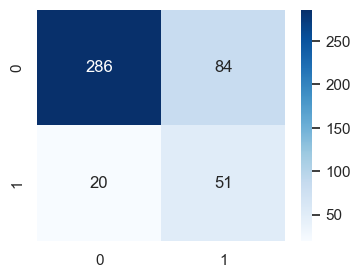

In [59]:
from sklearn.metrics import confusion_matrix
demo.fit(X_train, y_train)
y_pred = demo.predict(X_valid)
print("재현율 :", round(recall_score(y_valid, y_pred, zero_division=0), 4))
print("정확도 :", round(accuracy_score(y_valid, y_pred), 4))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt=".0f", cmap="Blues")

---
# 5. 기준선 (Baseline) — 넘어야 할 선을 먼저 그린다

복잡한 모델부터 시작하면, 성능이 잘 나와도 "데이터가 좋아서인지 모델이 좋아서인지" 알 수 없다.
**세 가지 기준선**을 먼저 만든다.

**실행 전에 예상해 보라** — "전원 재직으로 예측"하는 모델의 정확도는 얼마일 것 같은가?
그리고 그 모델의 **재현율**은 얼마일까?


In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, f1_score, roc_auc_score, confusion_matrix


def evaluate(name, y_true, y_pred, y_proba=None):
    """지표를 한 줄(dict)로 정리해 반환한다."""
    return {
        "모델": name,
        "정확도": round(accuracy_score(y_true, y_pred), 4),
        "재현율": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "정밀도": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else np.nan,
    }


baselines = []

# ① 다수 클래스 — 전원 '재직'으로 예측한다
dummy_major = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baselines.append(evaluate("① 다수 클래스(전원 재직)", y_valid,
                          dummy_major.predict(X_valid),
                          dummy_major.predict_proba(X_valid)[:, 1]))

# ② 무작위 — 클래스 비율대로 찍는다
dummy_rand = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE).fit(X_train, y_train)
baselines.append(evaluate("② 무작위(클래스 비율)", y_valid,
                          dummy_rand.predict(X_valid),
                          dummy_rand.predict_proba(X_valid)[:, 1]))

# ③ 단일 규칙 — 야근하면 퇴사로 본다 (모델이 아니라 if 한 줄)
rule_pred = (X_valid["OverTime"] == "Yes").astype(int).values
baselines.append(evaluate("③ 규칙(OverTime=Yes)", y_valid, rule_pred, rule_pred.astype(float)))

baseline_df = pd.DataFrame(baselines)
print("기준선 3종이 채워졌는지 확인:", len(baseline_df), "행")
baseline_df

기준선 3종이 채워졌는지 확인: 3 행


,모델,정확도,재현율,정밀도,F1,ROC-AUC
0,① 다수 클래스(전원 재직),0.8390,0.0000,0.0000,0.0000,0.5000
1,② 무작위(클래스 비율),0.7211,0.1690,0.1579,0.1633,0.4980
2,③ 규칙(OverTime=Yes),0.7324,0.5634,0.3150,0.4040,0.6641


> **읽는 법**
> 정확도 84%짜리 모델은 "아무것도 학습하지 않은 모델과 같다"는 뜻일 수 있다.
> 반대로 "OverTime 한 줄 규칙"이 재현율 0.5 를 낸다면, 그보다 낮은 재현율의 복잡한 모델은 존재 이유가 없다.


In [61]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — evaluate() 와 기준선 3종
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = True

if USE_RESCUE:
    def evaluate(name, y_true, y_pred, y_proba=None):
        return {
            "모델": name,
            "정확도": round(accuracy_score(y_true, y_pred), 4),
            "재현율": round(recall_score(y_true, y_pred, zero_division=0), 4),
            "정밀도": round(precision_score(y_true, y_pred, zero_division=0), 4),
            "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
            "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else np.nan,
        }

    baselines = []
    d1 = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
    baselines.append(evaluate("① 다수 클래스(전원 재직)", y_valid, d1.predict(X_valid),
                              d1.predict_proba(X_valid)[:, 1]))
    d2 = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE).fit(X_train, y_train)
    baselines.append(evaluate("② 무작위(클래스 비율)", y_valid, d2.predict(X_valid),
                              d2.predict_proba(X_valid)[:, 1]))
    rule_pred = (X_valid["OverTime"] == "Yes").astype(int).values
    baselines.append(evaluate("③ 규칙(OverTime=Yes)", y_valid, rule_pred, rule_pred.astype(float)))
    print(pd.DataFrame(baselines).to_string(index=False))
    print('구제 코드를 사용했습니다 — evaluate() 와 기준선 3종')

                모델    정확도    재현율    정밀도     F1  ROC-AUC
   ① 다수 클래스(전원 재직) 0.8390 0.0000 0.0000 0.0000   0.5000
     ② 무작위(클래스 비율) 0.7211 0.1690 0.1579 0.1633   0.4980
③ 규칙(OverTime=Yes) 0.7324 0.5634 0.3150 0.4040   0.6641
구제 코드를 사용했습니다 — evaluate() 와 기준선 3종


---
# 6. 모델 비교 실험 (수업 · 핵심)

**한 번에 하나씩 바꾼다.** 여기서는 모델 종류만 바꾸고 나머지(분할·전처리·지표)는 모두 고정한다.

**실행 전에 예상해 보라** — 아래 7개 모델 중 **재현율**이 가장 높을 것 같은 모델은?
그리고 **정확도**가 가장 높을 것 같은 모델은? 두 답이 같은가, 다른가?


In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

candidates = {
    "로지스틱 회귀":        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "로지스틱(balanced)":   LogisticRegression(max_iter=1000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "결정트리":             DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "랜덤 포레스트":        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "그래디언트 부스팅":    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN (k=7)":            KNeighborsClassifier(n_neighbors=7),
    "선형 SVM":             CalibratedClassifierCV(LinearSVC(max_iter=5000,
                                                            random_state=RANDOM_STATE), cv=3),
}

results = list(baselines)
fitted = {}

for name, model in candidates.items():
    # 전처리 + 모델을 하나의 파이프라인으로 — 폴드/분할마다 전처리가 다시 fit 된다
    pipe = Pipeline([("pre", make_preprocessor()), ("model", model)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_valid)
    proba = pipe.predict_proba(X_valid)[:, 1]

    results.append(evaluate(name, y_valid, pred, proba))
    fitted[name] = pipe
    print(f"학습 완료 — {name}")

model_table = pd.DataFrame(results)
if "재현율" in model_table.columns:
    model_table = model_table.sort_values("재현율", ascending=False).reset_index(drop=True)
else:
    print("→ 아직 결과가 비어 있습니다. 위 TODO 를 완성하거나 아래 구제 셀을 사용하세요.")
model_table

학습 완료 — 로지스틱 회귀
학습 완료 — 로지스틱(balanced)
학습 완료 — 결정트리
학습 완료 — 랜덤 포레스트
학습 완료 — 그래디언트 부스팅
학습 완료 — KNN (k=7)
학습 완료 — 선형 SVM


,모델,정확도,재현율,정밀도,F1,ROC-AUC
0,로지스틱(balanced),0.7642,0.7183,0.3778,0.4951,0.8174
1,③ 규칙(OverTime=Yes),0.7324,0.5634,0.3150,0.4040,0.6641
2,그래디언트 부스팅,0.8662,0.2958,0.7000,0.4158,0.8345
3,로지스틱 회귀,0.8730,0.2817,0.8000,0.4167,0.8130
4,선형 SVM,0.8662,0.2394,0.7727,0.3656,0.8085
5,랜덤 포레스트,0.8594,0.2113,0.7143,0.3261,0.8174
6,결정트리,0.8186,0.1831,0.3714,0.2453,0.7072
7,② 무작위(클래스 비율),0.7211,0.1690,0.1579,0.1633,0.4980
8,KNN (k=7),0.8390,0.0986,0.5000,0.1647,0.6894
9,① 다수 클래스(전원 재직),0.8390,0.0000,0.0000,0.0000,0.5000


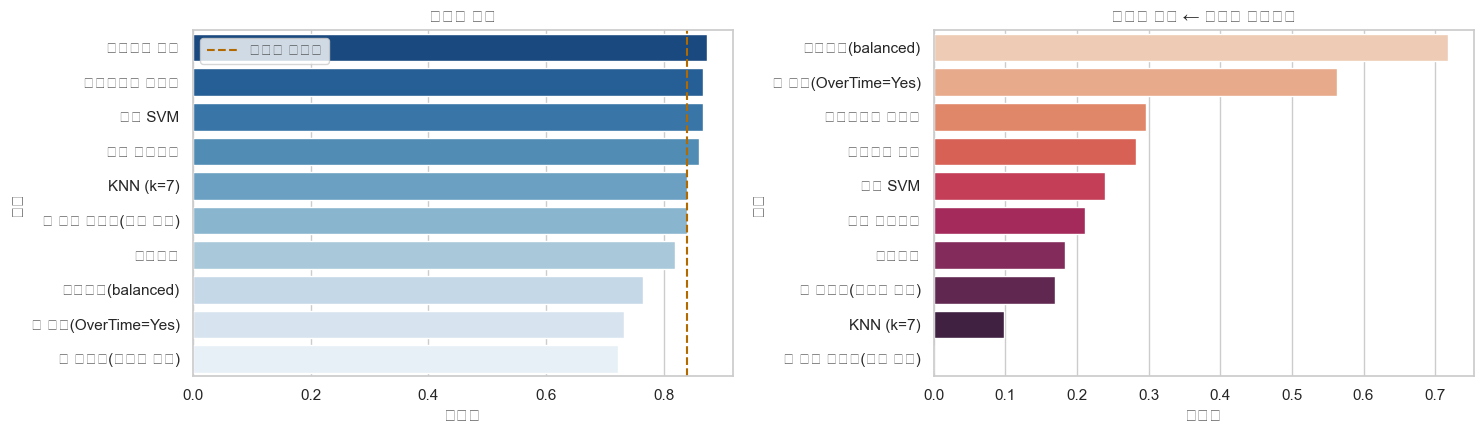

두 순위를 비교해 보라. 예상과 맞았는가?
정확도 1위 모델과 재현율 1위 모델이 다르다면, 우리는 어느 쪽을 골라야 하는가?
→ 답은 1단계 요구사항 명세 카드의 '성능 우선순위' 항목에 이미 적혀 있다.


In [63]:
# 정확도 순위와 재현율 순위가 어떻게 다른지 눈으로 확인
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
acc = model_table.sort_values("정확도", ascending=False)
rec = model_table.sort_values("재현율", ascending=False)
sns.barplot(data=acc, y="모델", x="정확도", ax=axes[0], palette="Blues_r")
axes[0].axvline(1 - y.mean(), color="#B26A00", ls="--", label="기준선 정확도")
axes[0].legend(); axes[0].set_title("정확도 순위")
sns.barplot(data=rec, y="모델", x="재현율", ax=axes[1], palette="rocket_r")
axes[1].set_title("재현율 순위 ← 우리의 요구사항")
plt.tight_layout(); plt.show()

print("두 순위를 비교해 보라. 예상과 맞았는가?")
print("정확도 1위 모델과 재현율 1위 모델이 다르다면, 우리는 어느 쪽을 골라야 하는가?")
print("→ 답은 1단계 요구사항 명세 카드의 '성능 우선순위' 항목에 이미 적혀 있다.")

---
# 7. 클래스 불균형 대응 비교

세 가지 접근을 **같은 모델·같은 분할**로 비교한다.

| 방법 | 설명 |
|---|---|
| 없음 | 아무 대응도 하지 않는다 |
| class_weight | 손실함수에서 소수 클래스의 오답에 더 큰 벌점 (데이터는 그대로) |
| SMOTE | 소수 클래스의 합성 샘플을 생성해 수를 늘린다 (**훈련 데이터에만**) |


In [64]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMB_OK = True
except ImportError:
    IMB_OK = False
    print("imbalanced-learn 이 없습니다 → 새 셀에서 !pip install -q imbalanced-learn 실행 후 다시 실행")

imb_results = []
imb_models = {}

# (A) 대응 없음
pipe_none = Pipeline([("pre", make_preprocessor()),
                      ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
pipe_none.fit(X_train, y_train)
imb_models["(A) 없음"] = pipe_none
imb_results.append(evaluate("(A) 대응 없음", y_valid, pipe_none.predict(X_valid),
                            pipe_none.predict_proba(X_valid)[:, 1]))

# (B) class_weight="balanced" — 데이터는 그대로 두고 손실함수의 벌점만 바꾼다
pipe_cw = Pipeline([("pre", make_preprocessor()),
                    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                 random_state=RANDOM_STATE))])
pipe_cw.fit(X_train, y_train)
imb_models["(B) class_weight"] = pipe_cw
imb_results.append(evaluate("(B) class_weight=balanced", y_valid, pipe_cw.predict(X_valid),
                            pipe_cw.predict_proba(X_valid)[:, 1]))

# (C) SMOTE — 합성 샘플 생성. 반드시 파이프라인 '안'에 넣어 훈련 데이터에만 적용되게 한다
if IMB_OK:
    pipe_smote = ImbPipeline([("pre", make_preprocessor()),
                              ("smote", SMOTE(random_state=RANDOM_STATE)),
                              ("model", LogisticRegression(max_iter=1000,
                                                           random_state=RANDOM_STATE))])
    pipe_smote.fit(X_train, y_train)
    imb_models["(C) SMOTE"] = pipe_smote
    imb_results.append(evaluate("(C) SMOTE", y_valid, pipe_smote.predict(X_valid),
                                pipe_smote.predict_proba(X_valid)[:, 1]))

imb_table = pd.DataFrame(imb_results)
imb_table

imbalanced-learn 이 없습니다 → 새 셀에서 !pip install -q imbalanced-learn 실행 후 다시 실행


,모델,정확도,재현율,정밀도,F1,ROC-AUC
0,(A) 대응 없음,0.8730,0.2817,0.8000,0.4167,0.8130
1,(B) class_weight=balanced,0.7642,0.7183,0.3778,0.4951,0.8174


### 실습 7-1. 재현율–정밀도 교환관계 확인

세 방법의 혼동행렬을 나란히 그려, **놓친 퇴사자(FN)** 와 **헛된 면담(FP)** 이 어떻게 맞바뀌는지 확인하라.


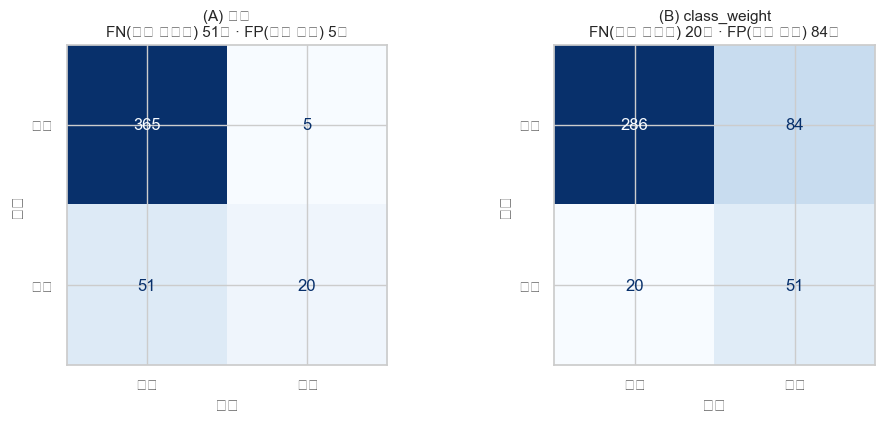

              방법  TP  FN(놓침)  FP(헛된 면담)    재현율    정밀도
          (A) 없음  20      51          5 0.2817 0.8000
(B) class_weight  51      20         84 0.7183 0.3778

→ FN 이 줄면 FP 가 늘어난다. 둘을 동시에 줄일 수는 없다(교환관계).
   '놓친 퇴사자 1명의 비용'과 '헛된 면담 1건의 비용' 중 무엇이 더 큰가로 방법을 고른다.
   (그 비용 계산은 4차시의 임계값 결정에서 이어서 다룬다.)


In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(imb_models), figsize=(5 * len(imb_models), 4.4))
axes = np.atleast_1d(axes)

summary = []
for ax, (label, model) in zip(axes, imb_models.items()):
    cm = confusion_matrix(y_valid, model.predict(X_valid))
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(cm, display_labels=["재직", "퇴사"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{label}\nFN(놓친 퇴사자) {fn}명 · FP(헛된 면담) {fp}명", fontsize=11)
    ax.set_xlabel("예측"); ax.set_ylabel("실제")
    summary.append({"방법": label, "TP": tp, "FN(놓침)": fn, "FP(헛된 면담)": fp,
                    "재현율": round(tp / (tp + fn), 4),
                    "정밀도": round(tp / (tp + fp), 4) if (tp + fp) else 0.0})

plt.tight_layout(); plt.show()

print(pd.DataFrame(summary).to_string(index=False))
print("\n→ FN 이 줄면 FP 가 늘어난다. 둘을 동시에 줄일 수는 없다(교환관계).")
print("   '놓친 퇴사자 1명의 비용'과 '헛된 면담 1건의 비용' 중 무엇이 더 큰가로 방법을 고른다.")
print("   (그 비용 계산은 4차시의 임계값 결정에서 이어서 다룬다.)")

---
# 8. 딥러닝(DNN) 비교  


## 먼저 예측해 보라 (실행 전에 답할 것)

지금까지 만든 로지스틱 회귀·랜덤 포레스트와 비교했을 때, **딥러닝은 몇 등쯤 할 것 같은가?**
그리고 그렇게 예상한 이유는 무엇인가?

| 판단 근거 | 이 사례의 조건 | 딥러닝에 유리한가? |
|---|---|---|
| 데이터 유형 | 정형(표 형태) 21개 피처 | ? |
| 데이터 규모 | 1,470건 | ? |
| 요구사항 | 예측 근거 설명 필요 | ? |
| 자원 | GPU 없음 | ? |

**예상: ______등 / 이유: ____________________**

---


In [66]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    TF_OK = True
except Exception as e:
    TF_OK = False
    print("TensorFlow 를 불러올 수 없습니다:", e)
    print("Colab 에서는 기본 설치되어 있습니다. 로컬이라면 !pip install tensorflow")

In [67]:
if TF_OK:
    pre_dnn = make_preprocessor()
    Xtr_d = np.asarray(pre_dnn.fit_transform(X_train), dtype="float32")
    Xva_d = np.asarray(pre_dnn.transform(X_valid), dtype="float32")

    tf.random.set_seed(RANDOM_STATE)

    dnn = Sequential([
        tf.keras.Input(shape=(Xtr_d.shape[1],)),   # = input_shape=(피처 수,)
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),            # 이진 분류 → 확률 1개
    ])

    dnn.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
    )

    dnn.summary()
    print(f"\n입력 피처 {Xtr_d.shape[1]}개 · 훈련 {Xtr_d.shape[0]}건 "
          f"→ 학습할 파라미터 {dnn.count_params():,}개")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)


입력 피처 25개 · 훈련 1029건 → 학습할 파라미터 1,377개


In [68]:
if TF_OK:
    # 1) 클래스 가중치 — 소수 클래스(퇴사)의 오답에 더 큰 벌점을 준다
    n0 = int((y_train == 0).sum())
    n1 = int((y_train == 1).sum())
    cw = {0: len(y_train) / (2 * n0), 1: len(y_train) / (2 * n1)}
    print("클래스 가중치:", {k: round(v, 3) for k, v in cw.items()})

    # 2) 콜백 — val_loss 가 아니라 val_recall 을 기준으로 멈추고 저장한다.
    #    우리 요구사항은 '퇴사자를 놓치지 않는 것'이다. 손실이 조금 나빠져도
    #    재현율이 가장 높았던 시점의 가중치를 남기는 편이 요구사항에 맞다.
    es = EarlyStopping(monitor="val_recall", mode="max",
                       patience=20, restore_best_weights=True)
    mc = ModelCheckpoint("best_dnn.keras", monitor="val_recall", mode="max",
                         save_best_only=True)

    # 3) 학습
    history = dnn.fit(
        Xtr_d, y_train.values,
        epochs=200, batch_size=32,
        validation_data=(Xva_d, y_valid.values),
        class_weight=cw,
        callbacks=[es, mc],
        verbose=0,
    )

    n_epoch = len(history.history["loss"])
    print(f"학습 종료 — {n_epoch} epoch 에서 중단 "
          f"(최고 val_recall {max(history.history['val_recall']):.4f})")

클래스 가중치: {0: 0.596, 1: 3.099}
학습 종료 — 22 epoch 에서 중단 (최고 val_recall 0.7042)


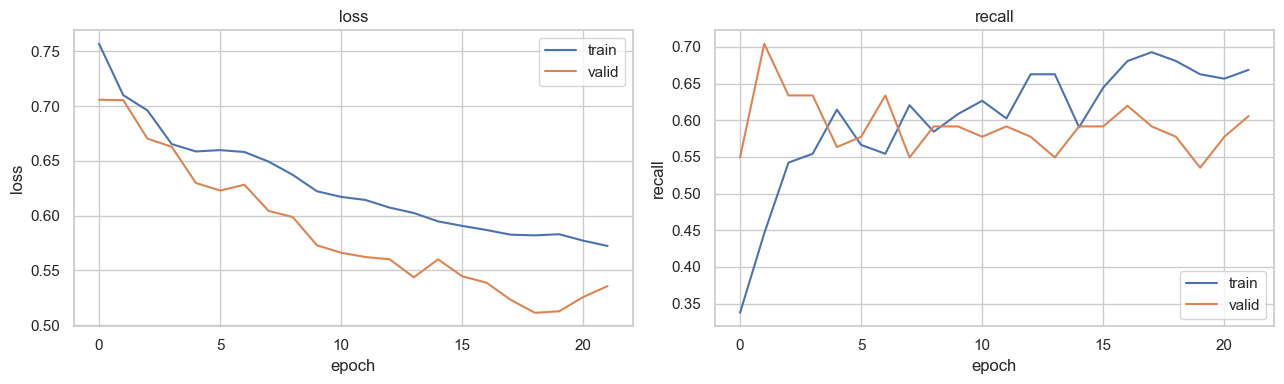

            모델     정확도     재현율     정밀도     F1  ROC-AUC
0  DNN (2 은닉층)  0.4422  0.7042  0.1818  0.289   0.5739


In [69]:
if TF_OK:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, key in zip(axes, ["loss", "recall"]):
        ax.plot(history.history[key], label="train")
        ax.plot(history.history["val_" + key], label="valid")
        ax.set_xlabel("epoch"); ax.set_ylabel(key); ax.legend(); ax.set_title(key)
    plt.tight_layout(); plt.show()

    dnn_proba = dnn.predict(Xva_d, verbose=0).ravel()
    dnn_pred = (dnn_proba >= 0.5).astype(int)
    dnn_row = evaluate("DNN (2 은닉층)", y_valid, dnn_pred, dnn_proba)
    print(pd.DataFrame([dnn_row]))

### [작성] 딥러닝과 머신러닝 모델 비교 결론

DNN 의 성능을 6절의 모델 비교표와 대조하고, 아래 질문에 답하라.

1. DNN 이 머신러닝 모델보다 나은가, 못한가? 수치로 말하라.
2. 그 이유는 무엇이라고 생각하는가? (데이터 규모 / 데이터 유형 / 과적합)
3. 성능이 비슷하다면 어떤 모델을 선택해야 하는가? 1단계 요구사항을 근거로 답하라.
4. 이 결론이 5차시의 시각 검색 문제에도 그대로 적용될까? 무엇이 달라지면 결론이 뒤집히는가?

**결론**:

1. DNN의 검증 정확도는 [DNN 정확도], 재현율은 [DNN 재현율], 
F1은 [DNN F1], ROC-AUC는 [DNN ROC-AUC]였다.  
6절에서 재현율이 가장 높았던 로지스틱 회귀(balanced)는 정확도 0.7642,
재현율 0.7183, F1 0.4951, ROC-AUC 0.8174였다. 따라서 재현율을
기준으로 DNN은 로지스틱 회귀보다 [높았다/낮았다/비슷했다].

2. 이 데이터는 약 1,470건의 소규모 정형 데이터이며 피처 수도 많지 않다.
DNN은 많은 데이터에서 복잡한 비선형 패턴을 학습할 때 강하지만, 이 사례에서는
학습 데이터가 적어 장점을 충분히 활용하기 어렵고 과적합 가능성도 크다.
반면 로지스틱 회귀와 트리 기반 모델은 이러한 표 형태의 소규모 데이터에
상대적으로 적합하다.

3. 성능이 비슷하다면 로지스틱 회귀(balanced)를 선택하겠다. 1단계 요구사항에서
퇴사자를 놓치지 않는 것이 중요하므로 정확도보다 재현율을 우선해야 하며,
인사팀이 예측 근거를 설명할 수 있어야 한다. 로지스틱 회귀는 DNN보다 변수별
영향을 설명하기 쉽고, 학습과 운영 비용도 작으며 결과를 재현하기도 쉽다.
따라서 DNN의 성능 향상이 크지 않다면 복잡한 DNN을 사용할 실익이 없다.

4. 이 결론은 5차시의 시각 검색 문제에는 그대로 적용되지 않는다. 이미지는
픽셀로 구성된 고차원 비정형 데이터이므로 사람이 직접 유용한 피처를 정의하기
어렵고, CNN이나 사전 학습된 비전 모델이 특징을 자동으로 추출하는 데 유리하다.
이미지 데이터가 충분히 많아지거나 사전 학습 모델을 전이학습하고 GPU를 사용할
수 있다면 딥러닝의 성능이 크게 향상되어 이번 결론이 뒤집힐 수 있다.

도구는 문제조건에 따라 고른다.

---
# 9. 모델 해석과 저장

1단계에서 "인사팀이 예측 근거를 설명할 수 있어야 한다"고 합의했다. 그 요구사항을 이행한다.


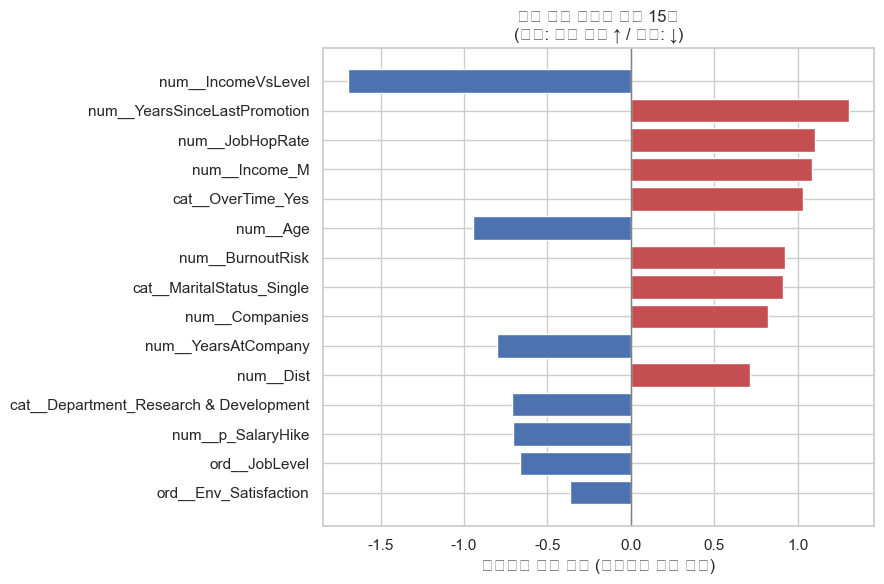

,피처,계수,크기
9,num__IncomeVsLevel,-1.697084,1.697084
6,num__YearsSinceLastPromotion,1.305603,1.305603
8,num__JobHopRate,1.100350,1.100350
0,num__Income_M,1.085418,1.085418
16,cat__OverTime_Yes,1.028448,1.028448
2,num__Age,-0.944092,0.944092
10,num__BurnoutRisk,0.923882,0.923882
15,cat__MaritalStatus_Single,0.909535,0.909535
4,num__Companies,0.819605,0.819605
5,num__YearsAtCompany,-0.804524,0.804524


퇴사 확률을 높이는 상위 5개
                          피처    계수
num__YearsSinceLastPromotion 1.306
             num__JobHopRate 1.100
               num__Income_M 1.085
           cat__OverTime_Yes 1.028
            num__BurnoutRisk 0.924

퇴사 확률을 낮추는 상위 5개
                                    피처     계수
                    num__IncomeVsLevel -1.697
                              num__Age -0.944
                   num__YearsAtCompany -0.805
cat__Department_Research & Development -0.711
                     num__p_SalaryHike -0.708


In [70]:
# best_pipe = fitted["로지스틱(balanced)"]

# # 1) 변환 후 피처 이름   2) 모델 계수
# feat_names = best_pipe.named_steps["pre"].get_feature_names_out()
# coefs = best_pipe.named_steps["model"].coef_[0]

# # 3) 절댓값 상위 15개를 수평 막대그래프로
# coef_df = (pd.DataFrame({"피처": feat_names, "계수": coefs})
#            .assign(크기=lambda d: d["계수"].abs())
#            .sort_values("크기", ascending=False)
#            .head(15)
#            .sort_values("계수"))

# plt.figure(figsize=(9, 6))
# colors = ["#C44E52" if c > 0 else "#4C72B0" for c in coef_df["계수"]]
# plt.barh(coef_df["피처"], coef_df["계수"], color=colors)
# plt.axvline(0, color="gray", lw=1)
# plt.title("퇴사 예측 기여도 상위 15개  (빨강: 퇴사 확률 ↑ / 파랑: ↓)")
# plt.xlabel("로지스틱 회귀 계수 (표준화된 입력 기준)")
# plt.tight_layout(); plt.show()


# top_up = coef_df.sort_values("계수", ascending=False).head(5)
# top_down = coef_df.sort_values("계수").head(5)
# print("퇴사 확률을 높이는 상위 5개")
# print(top_up[["피처", "계수"]].round(3).to_string(index=False))
# print("\n퇴사 확률을 낮추는 상위 5개")
# print(top_down[["피처", "계수"]].round(3).to_string(index=False))



# # 4) 2차시 EDA 결론과 대조
# print("\n[2차시 EDA 결론과 대조]")
# print("  EDA: 야근(OverTime=Yes) · 미혼 · 낮은 직급 · 짧은 근속에서 퇴사율이 높았다.")
# print("  계수: 위 상위 목록에 OverTime / MaritalStatus / YearsAtCompany 계열이 있는지 확인하라.")
# print("  일치한다면 → 모델이 데이터에서 같은 신호를 배웠다는 뜻이다.")
# print("  어긋난다면 → 전처리 오류·누수·다중공선성 중 하나를 의심하고 원인을 기록하라.")
# print("\n※ 주의: 계수는 '상관'이지 '인과'가 아니다. 인사팀에 설명할 때 반드시 함께 전달할 것.")

best_pipe = fitted["로지스틱(balanced)"]

# 변환 후 피처 이름과 모델 계수
feat_names = best_pipe.named_steps["pre"].get_feature_names_out()
coefs = best_pipe.named_steps["model"].coef_[0]

# 계수 절댓값이 큰 피처 15개
coef_df = (
    pd.DataFrame({
        "피처": feat_names,
        "계수": coefs,
    })
    .assign(크기=lambda d: d["계수"].abs())
    .nlargest(15, "크기")
    .sort_values("크기", ascending=True)
)

# 그래프
plt.figure(figsize=(9, 6))

colors = [
    "#C44E52" if c > 0 else "#4C72B0"
    for c in coef_df["계수"]
]

plt.barh(
    coef_df["피처"],
    coef_df["계수"],
    color=colors,
)

plt.axvline(0, color="gray", linewidth=1)
plt.title("퇴사 예측 기여도 상위 15개\n(빨강: 퇴사 확률 ↑ / 파랑: ↓)")
plt.xlabel("로지스틱 회귀 계수 (표준화된 입력 기준)")
plt.tight_layout()
plt.show()

# imp.head(10) 대신 데이터프레임 출력
display(
    coef_df
    .sort_values("크기", ascending=False)
    .head(10)
)

top_up = coef_df.sort_values("계수", ascending=False).head(5)
top_down = coef_df.sort_values("계수", ascending=True).head(5)

print("퇴사 확률을 높이는 상위 5개")
print(top_up[["피처", "계수"]].round(3).to_string(index=False))

print("\n퇴사 확률을 낮추는 상위 5개")
print(top_down[["피처", "계수"]].round(3).to_string(index=False))

In [71]:
# 〔선택〕 순열 중요도 — 모델 종류와 무관하게 사용할 수 있다
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_pipe, X_valid, y_valid, scoring="recall",
                              n_repeats=10, random_state=RANDOM_STATE)
perm_df = (pd.DataFrame({"피처": X_valid.columns, "중요도": perm.importances_mean})
           .sort_values("중요도", ascending=False).reset_index(drop=True))
perm_df.head(10)

,피처,중요도
0,JobLevel,0.084507
1,OverTime,0.053521
2,Env_Satisfaction,0.043662
3,Department,0.036620
4,YearsSinceLastPromotion,0.021127
5,JobSatisfaction,0.021127
6,RelationshipSatisfaction,0.015493
7,p_SalaryHike,0.014085
8,YearsAtCompany,0.011268
9,IncomeVsLevel,0.009859


### 실습 9-1. 파이프라인 저장 (4차시에서 사용)

`joblib.dump()` 한 줄로 **전처리 + 모델이 함께** 저장된다. 이것이 3절에서 파이프라인으로 묶은 이유다.


In [72]:
import joblib, json, datetime

# 1) 전처리 + 모델이 '함께' 저장된다 — 이것이 파이프라인으로 묶은 이유다
joblib.dump(best_pipe, "hr_attrition_v1.pkl")

# 2) 모델만으로는 재현할 수 없는 정보를 메타데이터로 남긴다
final_row = [r for r in results if r["모델"] == "로지스틱(balanced)"][0]

meta = {
    "model_version": "v1",
    "algorithm": "LogisticRegression(class_weight='balanced', max_iter=1000)",
    "trained_at": str(datetime.date.today()),
    "random_state": RANDOM_STATE,
    "threshold": 0.5,
    "input_columns": list(X.columns),
    "use_derived_features": USE_FEATURES,
    "derived_features": NEW_FEATURES if USE_FEATURES else [],
    "valid_accuracy": final_row["정확도"],
    "valid_recall": final_row["재현율"],
    "valid_precision": final_row["정밀도"],
    "valid_roc_auc": final_row["ROC-AUC"],
    "baseline_accuracy": round(1 - y.mean(), 4),
}

with open("hr_attrition_v1.meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("저장 완료 — 이 두 파일이 있어야 4차시 실습을 시작할 수 있다")
print("  hr_attrition_v1.pkl       (전처리 + 모델)")
print("  hr_attrition_v1.meta.json (버전 · 임계값 · 입력 컬럼 · 성능)")
print()
print(json.dumps(meta, ensure_ascii=False, indent=2))

저장 완료 — 이 두 파일이 있어야 4차시 실습을 시작할 수 있다
  hr_attrition_v1.pkl       (전처리 + 모델)
  hr_attrition_v1.meta.json (버전 · 임계값 · 입력 컬럼 · 성능)

{
  "model_version": "v1",
  "algorithm": "LogisticRegression(class_weight='balanced', max_iter=1000)",
  "trained_at": "2026-09-22",
  "random_state": 2026,
  "threshold": 0.5,
  "input_columns": [
    "Income_M",
    "p_SalaryHike",
    "Age",
    "Dist",
    "Companies",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
    "PromotionStall",
    "JobHopRate",
    "IncomeVsLevel",
    "BurnoutRisk",
    "Education",
    "JobLevel",
    "JobSatisfaction",
    "Env_Satisfaction",
    "RelationshipSatisfaction",
    "Performance",
    "StockOption",
    "WorkLifeBalance",
    "Department",
    "Gender",
    "MaritalStatus",
    "OverTime"
  ],
  "use_derived_features": true,
  "derived_features": [
    "PromotionStall",
    "JobHopRate",
    "IncomeVsLevel",
    "BurnoutRisk"
  ],
  "valid_accuracy": 0.7642,
  "valid_recall": 0.7183,
  "valid_precision": 0.

In [73]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — 파이프라인 저장 (4차시 전제조건)
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    import joblib, json, datetime

    final_row = [r for r in results if r["모델"] == "로지스틱(balanced)"][0]
    meta = {
        "model_version": "v1",
        "algorithm": "LogisticRegression(class_weight='balanced', max_iter=1000)",
        "trained_at": str(datetime.date.today()),
        "random_state": RANDOM_STATE,
        "threshold": 0.5,
        "input_columns": list(X.columns),
        "use_derived_features": USE_FEATURES,
        "valid_accuracy": final_row["정확도"],
        "valid_recall": final_row["재현율"],
        "valid_precision": final_row["정밀도"],
        "valid_roc_auc": final_row["ROC-AUC"],
        "baseline_accuracy": round(1 - y.mean(), 4),
    }
    joblib.dump(best_pipe, "hr_attrition_v1.pkl")
    with open("hr_attrition_v1.meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print("저장 완료 — 이 두 파일이 있어야 4차시 실습을 시작할 수 있다")


In [74]:
# 저장한 파일이 실제로 동작하는지 확인 (배포 전 필수 점검)
loaded = joblib.load("hr_attrition_v1.pkl")
same = (loaded.predict_proba(X_valid)[:, 1] == best_pipe.predict_proba(X_valid)[:, 1]).all()
print("저장→로드 후 예측 일치:", "일치!" if same else "일치하지 않음!")

# 원본 형태의 DataFrame 한 건만 넣어도 동작하는가? (서빙 상황 모사)
one = X_valid.iloc[[0]]
print("단건 예측 확률:", round(float(loaded.predict_proba(one)[:, 1][0]), 4))

저장→로드 후 예측 일치: 일치!
단건 예측 확률: 0.6015


---
# 산출물 ④ 모델 카드 (Model Card)

아래 양식을 채워라. **"알려진 한계"와 "사용 조건"이 모델 카드의 핵심**이다.
성능 수치만 적힌 문서는 보고서이지 설계 문서가 아니다.

## 모델 카드

- **모델 이름** :
- **알고리즘** :
- **전처리** :
- **파생 피처** :
- **학습 데이터** :
- **검증 데이터** :
- **성능(검증)** :
- **기준선 대비** :
- **선택 이유** :
- **주요 피처** :
- **알려진 한계** :
- **사용 조건** :

---
# 제출

1. 모든 TODO 셀을 채우고 **런타임 → 모두 실행**이 오류 없이 끝나는지 확인한다.
2. **모델 비교 실험표**, **불균형 대응 비교표**, **모델 카드**가 모두 포함되었는지 확인한다.
3. `.ipynb` 파일과 `hr_attrition_v1.pkl`, `hr_attrition_v1.meta.json` 을 함께 제출한다.

## 다음 차시 (4차시) 예고

오늘 저장한 파이프라인을 불러와 5~7단계로 간다.
- 지표를 제대로 고르고, **임계값을 비용으로 결정**한다
- 민감 속성 그룹별 **공정성**을 측정한다
- 모델을 **배치 예측 서비스**로 만들고, **드리프트**를 감지해 재학습 시점을 판단한다
